<a href="https://colab.research.google.com/github/renad29amr/Juniors-2026/blob/main/Another_copy_of_NLP%2C_EDA_%26_Machine_Learning_on_USDA_Food_Product.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kanchana1990_food_ingredient_intelligence_database_path = kagglehub.dataset_download('kanchana1990/food-ingredient-intelligence-database')

print('Data source import complete.')


Using Colab cache for faster access to the 'food-ingredient-intelligence-database' dataset.
Data source import complete.




---

# 🥖 Ingredient Intelligence

## NLP, EDA & Machine Learning on USDA Food Product Ingredients

---

## 📌 Notebook Introduction

Modern food products contain complex ingredient formulations including base components, additives, preservatives, vitamins, and minerals. Understanding these formulations at scale is essential for **food safety, allergen detection, clean-label analysis, nutritional research, and product comparison**.

This notebook explores a **large-scale ingredient dataset (10,000+ food products)** sourced from **USDA FoodData Central**, containing detailed ingredient lists, brand information, serving sizes, and standardized food categories.

Using **Exploratory Data Analysis (EDA), Natural Language Processing (NLP), and Machine Learning**, we aim to uncover patterns hidden inside ingredient labels and demonstrate how ingredient text can be transformed into actionable insights.

### 🎯 Key Objectives

* Perform a **complete 30-step Exploratory Data Analysis**
* Clean and preprocess complex **ingredient text**
* Tokenize ingredients and analyze **frequency & formulation complexity**
* Automatically detect **major food allergens**
* Build **machine learning models** to predict food categories
* Construct **ingredient co-occurrence networks** to study formulation relationships

This notebook is designed to be:

* ✅ Beginner-friendly
* ✅ Research-oriented
* ✅ Kaggle-ready
* ✅ Extensible for real-world food analytics projects

---

## 📂 Dataset Summary

* **Source:** USDA FoodData Central (Public Domain)
* **Records:** 10,000+ food products
* **Ingredient Coverage:** 98.1%
* **Food Categories:** 58
* **Use Cases:** NLP, Allergen Detection, Food Analytics, ML Classification

---

## 📑 Table of Contents

### 1️⃣ Data Loading & Initial Setup

1. Import required libraries
2. Load the USDA food ingredient dataset
3. Inspect dataset shape and structure
4. Overview of columns and data types

---

### 2️⃣ Data Cleaning & Preprocessing

5. Missing value analysis
6. Handling missing brand information
7. Handling missing ingredient lists
8. Standardizing serving size units
9. Removing duplicates
10. Final data quality check

---

### 3️⃣ Exploratory Data Analysis (EDA)

11. Food category distribution
12. Search category analysis
13. Brand owner distribution
14. Serving size distribution
15. Serving unit analysis
16. Ingredient text length analysis
17. Ingredient count per product
18. Ingredient complexity by food category
19. Brand vs generic product comparison
20. Summary insights from EDA

---

### 4️⃣ Ingredient Text Processing (NLP)

21. Ingredient text cleaning
22. Tokenization of ingredient lists
23. Ingredient frequency analysis
24. Most common ingredients visualization
25. Ingredient diversity analysis

---

### 5️⃣ Allergen Detection System

26. Defining allergen keyword rules
27. Automatic allergen label generation
28. Allergen distribution analysis
29. Machine learning model for allergen detection

---

### 6️⃣ Food Category Prediction

30. Text vectorization using TF-IDF
31. Food category encoding
32. Machine learning model training
33. Model evaluation and performance metrics

---

### 7️⃣ Ingredient Co-occurrence Network

34. Building ingredient co-occurrence matrix
35. Network graph construction
36. Identifying highly connected ingredients
37. Interpretation of ingredient relationships

---

### 8️⃣ Conclusion & Future Work

38. Key findings and insights
39. Limitations of the study
40. Future improvements and research directions

---

## ✅ What You’ll Learn From This Notebook

* How to clean **real-world food label data**
* How to apply **NLP on ingredient text**
* How to detect allergens automatically
* How ingredient lists can predict food categories
* How to visualize formulation relationships using networks

---




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter


In [ ]:
df = pd.read_csv("/content/Food_Ingredient_Intelligence_Database.csv")

df.head()

,fdc_id,description,brand_owner,brand_name,ingredients,serving_size,serving_size_unit,food_category,search_category
0,2461174,"WHEAT BREAD, WHEAT","Bimbo Bakeries USA, Inc.",SELECT,"ENRICHED WHEAT FLOUR [FLOUR, MALTED BARLEY FLO...",41.0,g,Breads & Buns,wheat
1,2162090,"WHEAT BREAD, WHEAT",The Moran Group Incorporated,SAVE A LOT,"ENRICHED WHEAT FLOUR (FLOUR, MALTED BARLEY FLO...",26.0,g,Breads & Buns,wheat
2,2486543,"WHEAT BREAD, WHEAT","Bimbo Bakeries USA, Inc.",GOLDEN BAKE,"ENRICHED WHEAT FLOUR [FLOUR, MALTED BARLEY FLO...",26.0,g,Breads & Buns,wheat
3,2659727,"WHEAT BREAD, WHEAT","Meijer, Inc.",MEIJER,"ENRICHED UNBLEACHED FLOUR [WHEAT FLOUR, MALTED...",45.0,GRM,Breads & Buns,wheat
4,1948801,"WHEAT BREAD, WHEAT",The Kroger Co.,GOOD TO DOUGH,"ENRICHED FLOUR (WHEAT FLOUR, MALTED BARLEY, NI...",27.0,g,Breads & Buns,wheat


In [ ]:
df.shape

(12321, 9)

In [ ]:
df.isnull().sum()#that shows us all of the coulumns that has nulls

,0
fdc_id,0
description,0
brand_owner,83
brand_name,556
ingredients,188
serving_size,0
serving_size_unit,0
food_category,0
search_category,0


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
fdc_id,0.000000
description,0.000000
brand_owner,0.673647
brand_name,4.512621
ingredients,1.525850
serving_size,0.000000
serving_size_unit,0.000000
food_category,0.000000
search_category,0.000000


In [ ]:
df['brand_owner'].head(10)

,brand_owner
0,"Bimbo Bakeries USA, Inc."
1,The Moran Group Incorporated
2,"Bimbo Bakeries USA, Inc."
3,"Meijer, Inc."
4,The Kroger Co.
5,"Supervalu, Inc."
6,"Bimbo Bakeries USA, Inc."
7,The Kroger Co.
8,"Bimbo Bakeries USA, Inc."
9,Smart & Final Iris Corporation


In [ ]:
df['brand_owner'] = df['brand_owner'].fillna("Unknown")
df['brand_owner']

,brand_owner
0,"Bimbo Bakeries USA, Inc."
1,The Moran Group Incorporated
2,"Bimbo Bakeries USA, Inc."
3,"Meijer, Inc."
4,The Kroger Co.
...,...
12316,"Carr Valley Cheese Co., Inc."
12317,LUCCHETTI
12318,"Sam Tell & Son, Inc"
12319,Tea Trading Corp Of India


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
fdc_id,0.000000
description,0.000000
brand_owner,0.000000
brand_name,4.512621
ingredients,1.525850
serving_size,0.000000
serving_size_unit,0.000000
food_category,0.000000
search_category,0.000000


In [ ]:
df['brand_name']

,brand_name
0,SELECT
1,SAVE A LOT
2,GOLDEN BAKE
3,MEIJER
4,GOOD TO DOUGH
...,...
12316,CARR VALLEY CHEESE
12317,NaN
12318,SCHAR
12319,GREAT VALUE


In [ ]:
df['brand_name'] = df['brand_name'].fillna(df['brand_owner'])
df['brand_name'] = df['brand_name'].fillna("No Brand")

df['brand_name']


,brand_name
0,SELECT
1,SAVE A LOT
2,GOLDEN BAKE
3,MEIJER
4,GOOD TO DOUGH
...,...
12316,CARR VALLEY CHEESE
12317,LUCCHETTI
12318,SCHAR
12319,GREAT VALUE


In [ ]:
df = df.dropna(subset=['ingredients'])
#df['ingredients'] = df['ingredients'].dropna()

In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
fdc_id,0.000000
description,0.000000
brand_owner,0.000000
brand_name,3.898459
ingredients,0.000000
serving_size,0.000000
serving_size_unit,0.000000
food_category,0.000000
search_category,0.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12133 entries, 0 to 12320
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fdc_id             12133 non-null  int64  
 1   description        12133 non-null  object 
 2   brand_owner        12133 non-null  object 
 3   brand_name         11660 non-null  object 
 4   ingredients        12133 non-null  object 
 5   serving_size       12133 non-null  float64
 6   serving_size_unit  12133 non-null  object 
 7   food_category      12133 non-null  object 
 8   search_category    12133 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 947.9+ KB


In [ ]:
df['ingredients'] = df['ingredients'].fillna("Single Ingredient Product")


In [ ]:
df.head()

,fdc_id,description,brand_owner,brand_name,ingredients,serving_size,serving_size_unit,food_category,search_category
0,2461174,"WHEAT BREAD, WHEAT","Bimbo Bakeries USA, Inc.",SELECT,"ENRICHED WHEAT FLOUR [FLOUR, MALTED BARLEY FLO...",41.0,g,Breads & Buns,wheat
1,2162090,"WHEAT BREAD, WHEAT",The Moran Group Incorporated,SAVE A LOT,"ENRICHED WHEAT FLOUR (FLOUR, MALTED BARLEY FLO...",26.0,g,Breads & Buns,wheat
2,2486543,"WHEAT BREAD, WHEAT","Bimbo Bakeries USA, Inc.",GOLDEN BAKE,"ENRICHED WHEAT FLOUR [FLOUR, MALTED BARLEY FLO...",26.0,g,Breads & Buns,wheat
3,2659727,"WHEAT BREAD, WHEAT","Meijer, Inc.",MEIJER,"ENRICHED UNBLEACHED FLOUR [WHEAT FLOUR, MALTED...",45.0,GRM,Breads & Buns,wheat
4,1948801,"WHEAT BREAD, WHEAT",The Kroger Co.,GOOD TO DOUGH,"ENRICHED FLOUR (WHEAT FLOUR, MALTED BARLEY, NI...",27.0,g,Breads & Buns,wheat


In [ ]:
df['serving_size_unit'] = df['serving_size_unit'].str.lower()
df['serving_size_unit'] = df['serving_size_unit'].replace({'grm': 'g','grams': 'g'})


In [ ]:
df.head()

,fdc_id,description,brand_owner,brand_name,ingredients,serving_size,serving_size_unit,food_category,search_category
0,2461174,"WHEAT BREAD, WHEAT","Bimbo Bakeries USA, Inc.",SELECT,"ENRICHED WHEAT FLOUR [FLOUR, MALTED BARLEY FLO...",41.0,g,Breads & Buns,wheat
1,2162090,"WHEAT BREAD, WHEAT",The Moran Group Incorporated,SAVE A LOT,"ENRICHED WHEAT FLOUR (FLOUR, MALTED BARLEY FLO...",26.0,g,Breads & Buns,wheat
2,2486543,"WHEAT BREAD, WHEAT","Bimbo Bakeries USA, Inc.",GOLDEN BAKE,"ENRICHED WHEAT FLOUR [FLOUR, MALTED BARLEY FLO...",26.0,g,Breads & Buns,wheat
3,2659727,"WHEAT BREAD, WHEAT","Meijer, Inc.",MEIJER,"ENRICHED UNBLEACHED FLOUR [WHEAT FLOUR, MALTED...",45.0,g,Breads & Buns,wheat
4,1948801,"WHEAT BREAD, WHEAT",The Kroger Co.,GOOD TO DOUGH,"ENRICHED FLOUR (WHEAT FLOUR, MALTED BARLEY, NI...",27.0,g,Breads & Buns,wheat


some times we change the intire unit, we do calculate it then convert it;

as example from grams to pounds;

also if we are dealing with gold we can't use kelo grams so we convert to grams.

the unit observation must be done by agreement of the whole team working on the project.

In [ ]:
df.head(10)

,fdc_id,description,brand_owner,brand_name,ingredients,serving_size,serving_size_unit,food_category,search_category,ingredients_clean,ingredient_length,ingredient_tokens,num_ingredients,wheat,milk,soy,egg,category_encoded
0,2461174,"WHEAT BREAD, WHEAT","Bimbo Bakeries USA, Inc.",SELECT,"ENRICHED WHEAT FLOUR [FLOUR, MALTED BARLEY FLO...",41.0,g,Breads & Buns,wheat,"enriched wheat flour flour, malted barley flou...",391,"[enriched wheat flour flour, malted barley fl...",24,1,0,1,0,8
1,2162090,"WHEAT BREAD, WHEAT",The Moran Group Incorporated,SAVE A LOT,"ENRICHED WHEAT FLOUR (FLOUR, MALTED BARLEY FLO...",26.0,g,Breads & Buns,wheat,"enriched wheat flour flour, malted barley flou...",390,"[enriched wheat flour flour, malted barley fl...",21,1,0,1,0,8
2,2486543,"WHEAT BREAD, WHEAT","Bimbo Bakeries USA, Inc.",GOLDEN BAKE,"ENRICHED WHEAT FLOUR [FLOUR, MALTED BARLEY FLO...",26.0,g,Breads & Buns,wheat,"enriched wheat flour flour, malted barley flou...",391,"[enriched wheat flour flour, malted barley fl...",24,1,0,1,0,8
3,2659727,"WHEAT BREAD, WHEAT","Meijer, Inc.",MEIJER,"ENRICHED UNBLEACHED FLOUR [WHEAT FLOUR, MALTED...",45.0,g,Breads & Buns,wheat,"enriched unbleached flour wheat flour, malted ...",450,"[enriched unbleached flour wheat flour, malte...",24,1,0,1,0,8
4,1948801,"WHEAT BREAD, WHEAT",The Kroger Co.,GOOD TO DOUGH,"ENRICHED FLOUR (WHEAT FLOUR, MALTED BARLEY, NI...",27.0,g,Breads & Buns,wheat,"enriched flour wheat flour, malted barley, nia...",385,"[enriched flour wheat flour, malted barley, ...",22,1,0,1,0,8
5,2009341,"WHEAT BREAD, WHEAT","Supervalu, Inc.",ALBERTSONS,"UNBLEACHED ENRICHED FLOUR (WHEAT FLOUR, MALTED...",47.0,g,Breads & Buns,wheat,"unbleached enriched flour wheat flour, malted ...",747,"[unbleached enriched flour wheat flour, malte...",39,1,0,1,0,8
6,2256862,"WHEAT BREAD, WHEAT","Bimbo Bakeries USA, Inc.",SARA LEE,"INGREDIENTS: ENRICHED WHEAT FLOUR [FLOUR, MALT...",44.0,g,Breads & Buns,wheat,"ingredients enriched wheat flour flour, malted...",536,"[ingredients enriched wheat flour flour, malt...",32,1,0,1,0,8
7,1955829,"WHEAT BREAD, WHEAT",The Kroger Co.,QFC,"UNBLEACHED ENRICHED FLOUR (WHEAT FLOUR, MALTED...",29.0,g,Breads & Buns,wheat,"unbleached enriched flour wheat flour, malted ...",462,"[unbleached enriched flour wheat flour, malte...",25,1,0,1,0,8
8,2476648,"WHEAT BREAD, WHEAT","Bimbo Bakeries USA, Inc.",OLD HOME,"ENRICHED WHEAT FLOUR [FLOUR, MALTED BARLEY FLO...",41.0,g,Breads & Buns,wheat,"enriched wheat flour flour, malted barley flou...",396,"[enriched wheat flour flour, malted barley fl...",25,1,0,1,0,8
9,2486616,"WHEAT BREAD, WHEAT",Smart & Final Iris Corporation,SIMPLY VALUE,"ENRICHED WHEAT FLOUR (FLOUR, MALTED BARLEY FLO...",41.0,g,Breads & Buns,wheat,"enriched wheat flour flour, malted barley flou...",391,"[enriched wheat flour flour, malted barley fl...",24,1,0,1,0,8


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.

TypeError: NDFrame.first() missing 1 required positional argument: 'offset'

In [ ]:
df = df.drop_duplicates(subset=['fdc_id'])


In [ ]:
import re

def clean_ingredients(text):
    text = text.lower()
    text = re.sub(r'\[|\]', '', text)
    text = re.sub(r'\(|\)', '', text)
    text = re.sub(r'[^a-z, ]', '', text)
    return text

df['ingredients_clean'] = df['ingredients'].apply(clean_ingredients)


In [ ]:
df.isnull().sum()

,0
fdc_id,0
description,0
brand_owner,0
brand_name,473
ingredients,0
serving_size,0
serving_size_unit,0
food_category,0
search_category,0


In [ ]:

df.describe(include='all')


,fdc_id,description,brand_owner,brand_name,ingredients,serving_size,serving_size_unit,food_category,search_category,ingredients_clean,ingredient_length,ingredient_tokens,num_ingredients,wheat,milk,soy,egg,category_encoded
count,1.213300e+04,12133,12133,12133,12133,12133.000000,12133,12133,12133,12133,12133.000000,12133,12133.000000,12133.000000,12133.000000,12133.000000,12133.000000,12133.000000
unique,NaN,5689,2915,3882,9259,NaN,7,143,62,8922,NaN,8922,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"TOMATO PASTE, TOMATO",Target Stores,MEIJER,CANOLA OIL.,NaN,g,"Popcorn, Peanuts, Seeds & Related Snacks",wheat,walnuts,NaN,[walnuts],NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,108,364,243,112,NaN,10597,934,200,142,NaN,142,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.280376e+06,NaN,NaN,NaN,NaN,83.982664,NaN,NaN,NaN,NaN,216.722740,NaN,12.275612,0.282041,0.239265,0.278332,0.109948,72.868623
std,3.596057e+05,NaN,NaN,NaN,NaN,132.794999,NaN,NaN,NaN,NaN,232.453893,NaN,12.728137,0.450012,0.426652,0.448196,0.312838,42.013369
min,3.460550e+05,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.084567e+06,NaN,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,40.000000,NaN,2.000000,0.000000,0.000000,0.000000,0.000000,33.000000
50%,2.387974e+06,NaN,NaN,NaN,NaN,47.599998,NaN,NaN,NaN,NaN,144.000000,NaN,8.000000,0.000000,0.000000,0.000000,0.000000,73.000000
75%,2.542919e+06,NaN,NaN,NaN,NaN,107.000000,NaN,NaN,NaN,NaN,318.000000,NaN,17.000000,1.000000,0.000000,1.000000,0.000000,108.000000


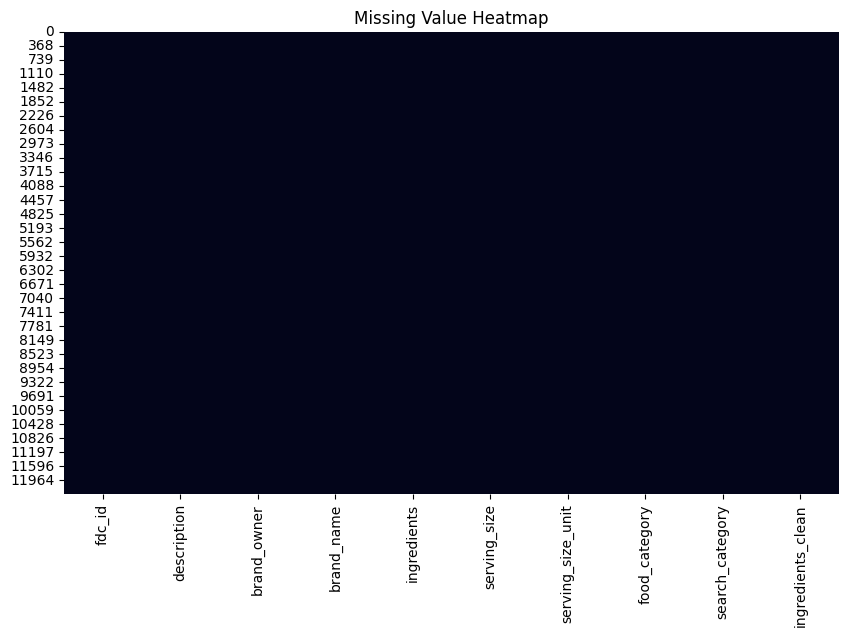

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()


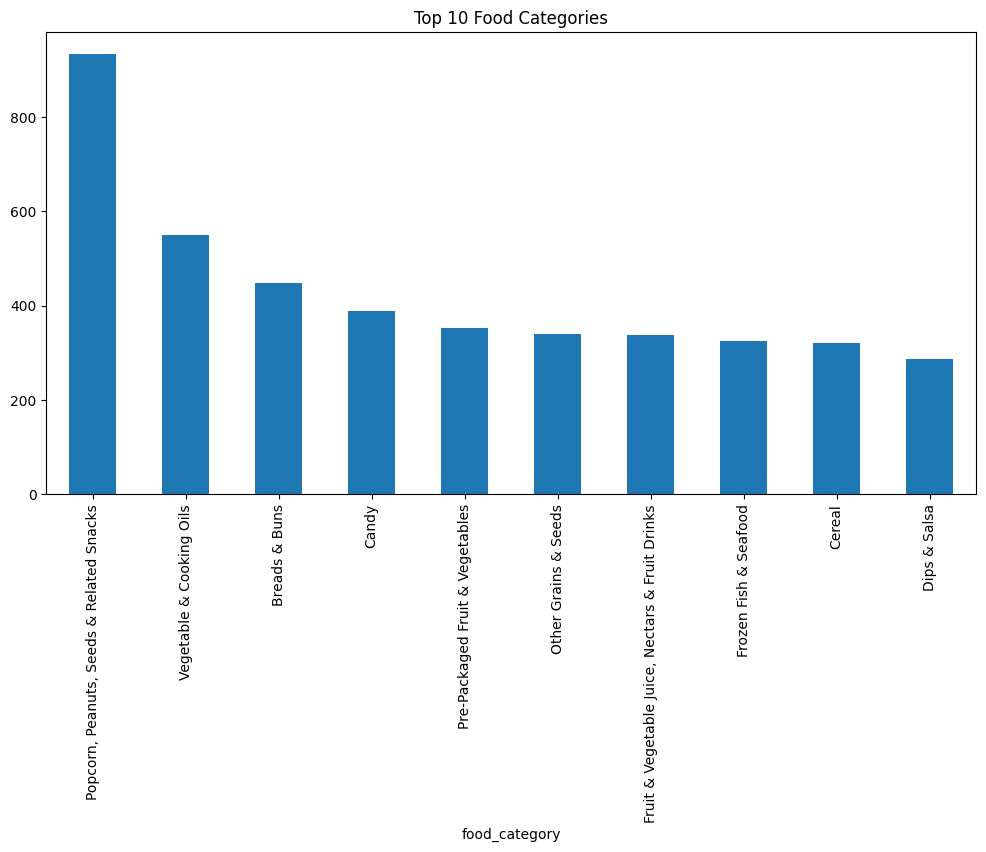

In [ ]:
plt.figure(figsize=(12,6))
df['food_category'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Food Categories")
plt.show()


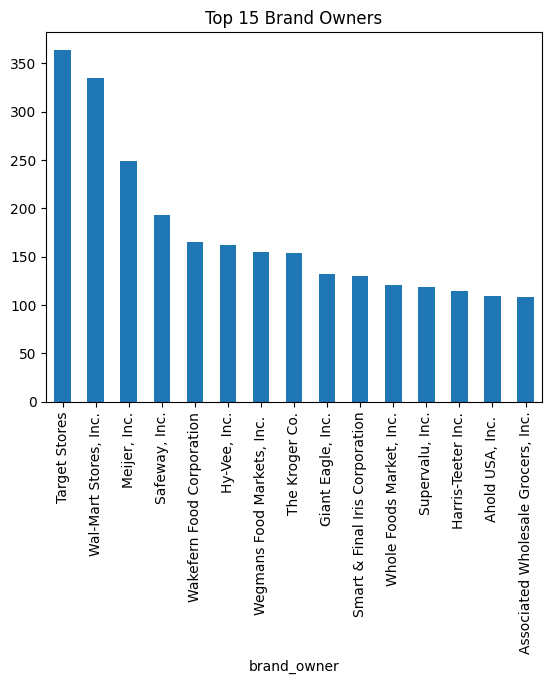

In [ ]:
df['brand_owner'].value_counts().head(15).plot(kind='bar')
plt.title("Top 15 Brand Owners")
plt.show()


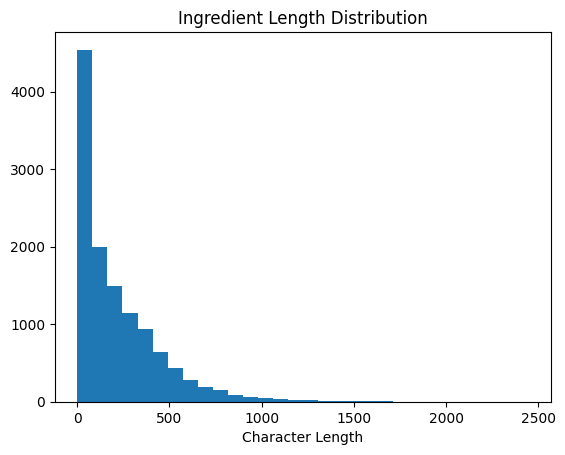

In [ ]:
df['ingredient_length'] = df['ingredients'].str.len()

plt.hist(df['ingredient_length'], bins=30)
plt.title("Ingredient Length Distribution")
plt.xlabel("Character Length")
plt.show()


<Axes: xlabel='search_category'>

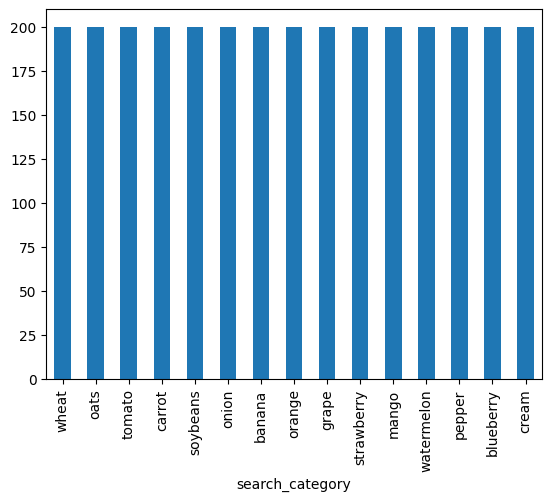

In [ ]:
df['search_category'].value_counts().head(15).plot(kind='bar')


<Axes: xlabel='brand_owner'>

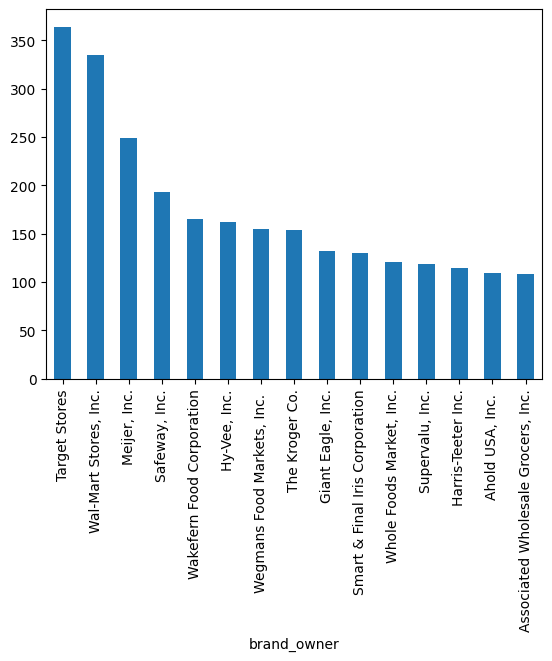

In [ ]:
df['brand_owner'].value_counts().head(15).plot(kind='bar')


<Axes: xlabel='serving_size', ylabel='Count'>

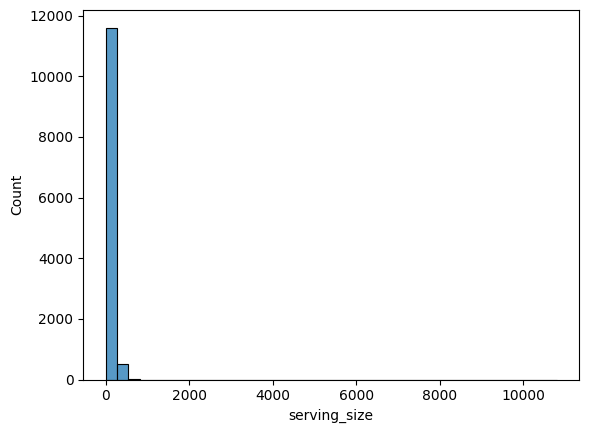

In [ ]:
sns.histplot(df['serving_size'], bins=40)


<Axes: ylabel='count'>

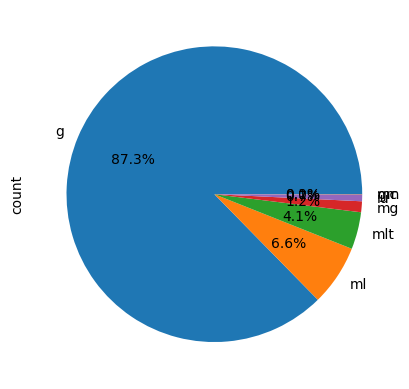

In [ ]:
df['serving_size_unit'].value_counts().plot(kind='pie', autopct='%1.1f%%')


<Axes: xlabel='ingredient_length', ylabel='Count'>

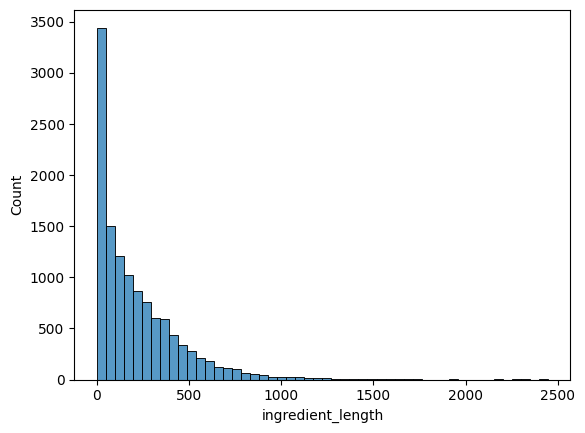

In [ ]:
df['ingredient_length'] = df['ingredients'].str.len()
sns.histplot(df['ingredient_length'], bins=50)


In [ ]:
df['ingredient_tokens'] = df['ingredients_clean'].str.split(',')


In [ ]:
all_ingredients = []
for row in df['ingredient_tokens']:
    all_ingredients.extend([i.strip() for i in row])


In [ ]:
ingredient_counts = Counter(all_ingredients)
top_20 = ingredient_counts.most_common(20)

pd.DataFrame(top_20, columns=['Ingredient', 'Count'])


,Ingredient,Count
0,salt,8663
1,water,5206
2,sugar,4377
3,citric acid,2346
4,folic acid,1862
5,niacin,1620
6,riboflavin,1536
7,natural flavor,1383
8,reduced iron,1382
9,sea salt,1257


<Axes: xlabel='Ingredient'>

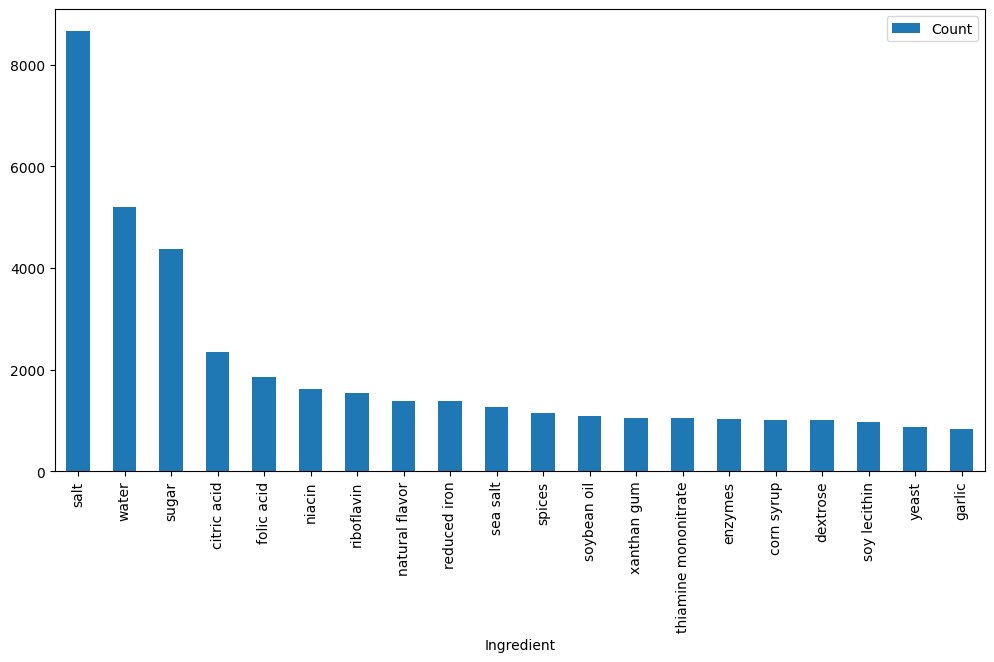

In [ ]:
pd.DataFrame(top_20, columns=['Ingredient', 'Count']).plot(
    x='Ingredient', y='Count', kind='bar', figsize=(12,6)
)


(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

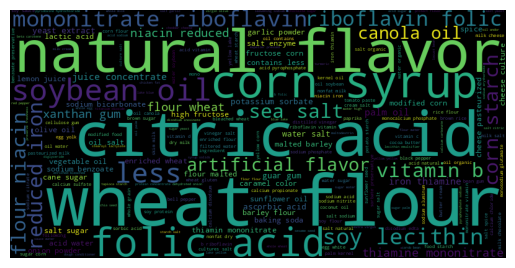

In [ ]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400).generate(" ".join(all_ingredients))
plt.imshow(wc)
plt.axis('off')


<Axes: xlabel='num_ingredients', ylabel='Count'>

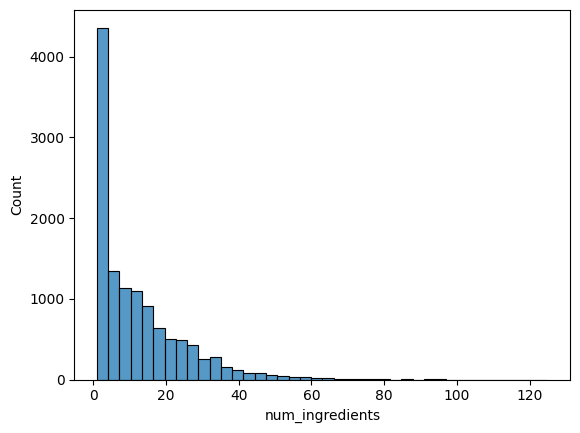

In [ ]:
df['num_ingredients'] = df['ingredient_tokens'].apply(len)
sns.histplot(df['num_ingredients'], bins=40)


<Axes: xlabel='food_category'>

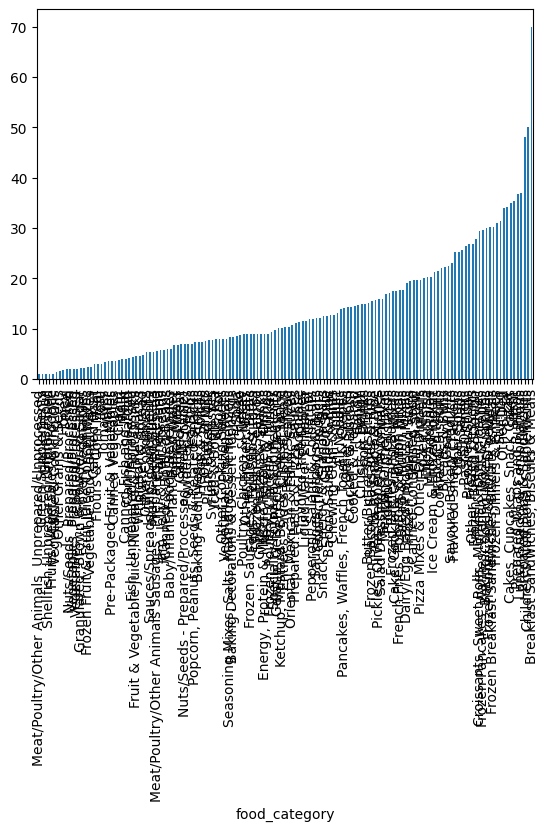

In [ ]:
df.groupby('food_category')['num_ingredients'].mean().sort_values().plot(kind='bar')


In [ ]:
allergens = {
    "wheat": ["wheat", "flour"],
    "milk": ["milk", "butter", "cream"],
    "soy": ["soy", "soybean"],
    "egg": ["egg"]
}


In [ ]:
for allergen, keywords in allergens.items():
    df[allergen] = df['ingredients_clean'].apply(
        lambda x: int(any(word in x for word in keywords))
    )


<Axes: >

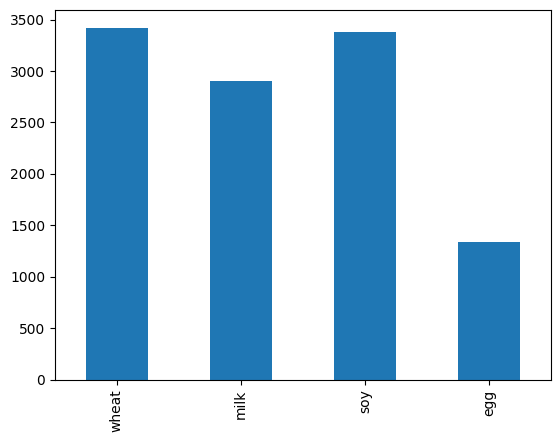

In [ ]:
df[['wheat','milk','soy','egg']].sum().plot(kind='bar')


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df['ingredients_clean']
y = df['wheat']  # example single allergen

vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1756
           1       1.00      0.90      0.95       671

    accuracy                           0.97      2427
   macro avg       0.98      0.95      0.96      2427
weighted avg       0.97      0.97      0.97      2427



In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['food_category'])


In [ ]:
X = df['ingredients_clean']
y = df['category_encoded']

X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         6
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         1
           7       0.00      0.00      0.00         4
           8       0.77      0.93      0.84        85
          10       0.91      0.84      0.88        25
          12       0.67      0.40      0.50         5
          13       0.73      0.82      0.77        45
          14       0.80      0.82      0.81        79
          15       0.90      0.90      0.90        20
          16       0.00      0.00      0.00         1
          18       1.00      0.95      0.97        19
          19       0.50      0.40      0.44         5
          20       0.80      0.96      0.87        49
          21       0.62    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

<Axes: >

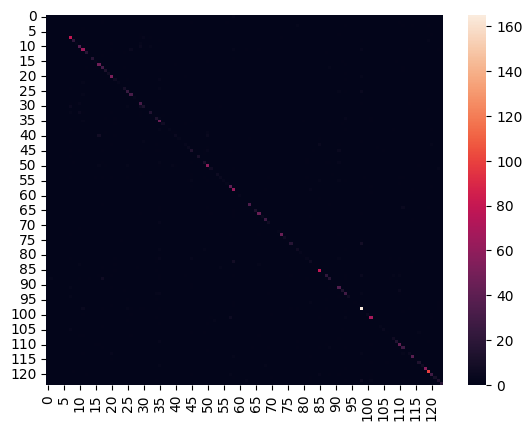

In [ ]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, pred))


In [ ]:
from itertools import combinations
import networkx as nx

co_occurrence = Counter()

for ingredients in df['ingredient_tokens']:
    for pair in combinations(set(ingredients), 2):
        co_occurrence[pair] += 1


In [ ]:
G = nx.Graph()

for (i1, i2), weight in co_occurrence.items():
    if weight > 50:
        G.add_edge(i1, i2, weight=weight)


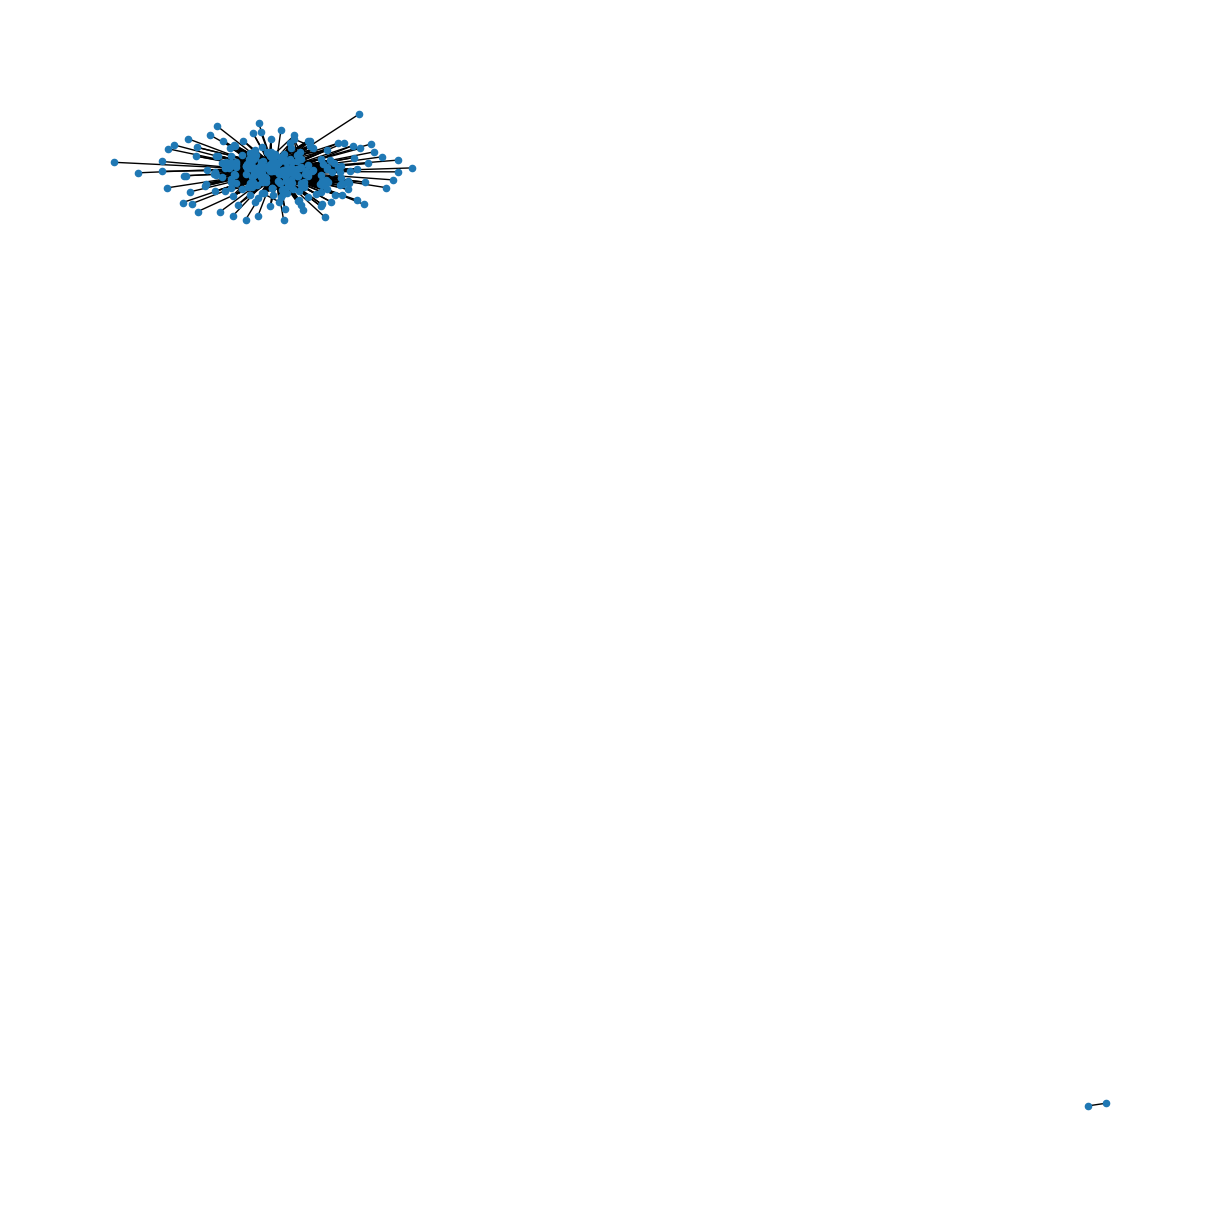

In [ ]:
plt.figure(figsize=(12,12))
nx.draw(G, with_labels=False, node_size=20)


In [ ]:
sorted(G.degree, key=lambda x: x[1], reverse=True)[:10]


[(' salt', 265),
 (' sugar', 208),
 (' water', 195),
 (' folic acid', 143),
 (' niacin', 124),
 (' citric acid', 117),
 (' reduced iron', 115),
 (' riboflavin', 113),
 (' soybean oil', 95),
 (' soy lecithin', 94)]